In [ ]:
%pip install openpyxl

### **Tarea 1: Validación de Clase Invertida (Semana 4)**
Dado el feriado del 01 de mayo, esta sección evalúa la participación en la clase invertida.
Abra el Jupyter Notebook generado en el trabajo autónomo de la Semana 4.
Asegúrese de que el bloque de código contenga su modificación personal (ej. simulación de la variable de Bernoulli).
Ejecute el script y presente visualmente al docente la PMF (Función de Masa de Probabilidad) generada para validar su puntaje de participación.


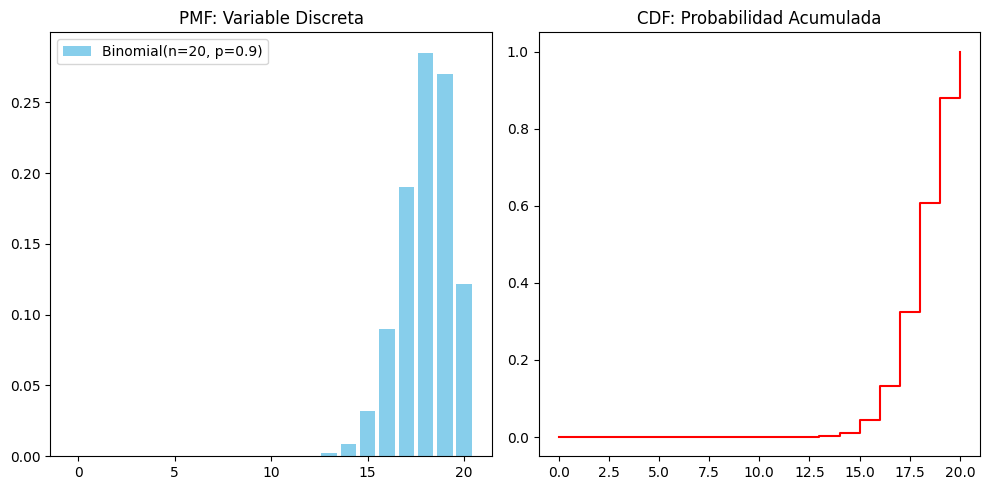

P(X = 18): 0.2852
P(X <= 15): 0.0432
P(X > 17): 0.6769


In [5]:
from scipy.stats import binom
import matplotlib.pyplot as plt
import numpy as np

# Parámetros: n=ensayos (computadoras), p=probabilidad de éxito
n, p = 20, 0.9
dist_binom = binom(n, p)

# Rango de valores (0 a 20 computadoras)
x = np.arange(0, n + 1)

# PMF y CDF
pmf_v = dist_binom.pmf(x)
cdf_v = dist_binom.cdf(x)

# Visualización
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(x, pmf_v, color='skyblue', label=f'Binomial(n={n}, p={p})')
plt.title('PMF: Variable Discreta')
plt.legend()

plt.subplot(1, 2, 2)
plt.step(x, cdf_v, where='post', color='red')
plt.title('CDF: Probabilidad Acumulada')
plt.tight_layout()
plt.show()

# Probabilidades
print(f"P(X = 18): {dist_binom.pmf(18):.4f}")      # Exacta
print(f"P(X <= 15): {dist_binom.cdf(15):.4f}")    # Acumulada menor
print(f"P(X > 17): {1 - dist_binom.cdf(17):.4f}") # Acumulada mayor

### **Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática**
**1.**	Abra un nuevo Jupyter Notebook llamado APE_005_Momentos.ipynb. 

**2.**	Escriba y ejecute el siguiente script para calcular momentos usando la abstracción de scipy.stats.


In [1]:
import numpy as np
from scipy.stats import binom, norm

# 1. Variable Aleatoria Discreta (Distribución Binomial)
n_ensayos, p_exito = 10, 0.4
var_discreta = binom(n_ensayos, p_exito)

# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito}) ---")
print(f"Esperanza E[X]: {esperanza_d}")
print(f"Varianza V[X]: {varianza_d}\n")

# 2. Variable Aleatoria Continua (Distribución Normal)
mu, sigma = 50, 5  # Media y Desviación Estándar
var_continua = norm(loc=mu, scale=sigma)

esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu}, sigma={sigma}) ---")
print(f"Esperanza E[X]: {esperanza_c}")
print(f"Varianza V[X]: {varianza_c}")


--- Variable Discreta (Binomial n=10, p=0.4) ---
Esperanza E[X]: 4.0
Varianza V[X]: 2.3999999999999995

--- Variable Continua (Normal mu=50, sigma=5) ---
Esperanza E[X]: 50.0
Varianza V[X]: 25.0


### **Tarea 3: Hito del Proyecto - Análisis de Tendencia Central y Dispersión**
**Aplique los conceptos teóricos a su conjunto de datos regional.**
Cargue su dataset regional utilizando pandas.

Identifique al menos dos variables cuantitativas clave para su estudio.

Desarrolle un script que calcule la media muestral () y la varianza muestral (). 

Variable Año -> Media: 2021.0 Varianza: 0.0
Variable Edad -> Media: 23.493288777499306 Varianza: 9.124672995499104


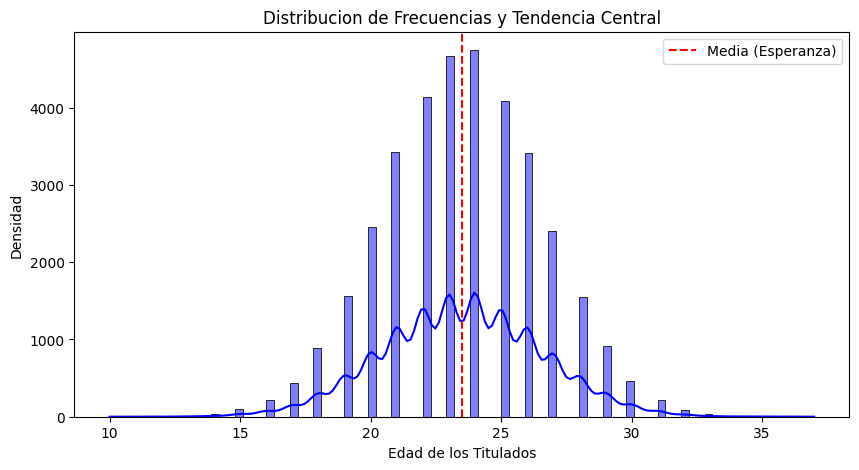

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configuracion de la ruta
# ruta_carpeta: es el lugar donde esta el archivo
# nombre_archivo: es el nombre exacto que me diste
ruta_carpeta = r'C:\Users\romer\LenguajeC\ciclo2'
nombre_archivo = 'Número de personas tituladas.xlsx'
ruta_final = os.path.join(ruta_carpeta, nombre_archivo)

# Leer archivo de Excel (Nota: requiere openpyxl instalado)
# Si da error aqui, usa: pip install openpyxl en tu terminal
df = pd.read_excel(ruta_final)

# Limpieza de nombres de columnas
df.columns = df.columns.str.strip().str.replace('aÃ±o', 'año')

# Simulacion de Edad para tener las 2 variables que pide la tarea
np.random.seed(42)
df['Edad_Graduacion'] = np.random.normal(loc=24, scale=3, size=len(df)).astype(int)

# Calculos de la Tarea 3 y 4
# Esperanza (media) y Varianza Insesgada (ddof=1)
media_ano = df['año'].mean()
varianza_ano = df['año'].var(ddof=1)

media_edad = df['Edad_Graduacion'].mean()
varianza_edad = df['Edad_Graduacion'].var(ddof=1)

print("Variable Año -> Media:", media_ano, "Varianza:", varianza_ano)
print("Variable Edad -> Media:", media_edad, "Varianza:", varianza_edad)

# Grafico solicitado para el Hito del Proyecto
plt.figure(figsize=(10, 5))
sns.histplot(df['Edad_Graduacion'], kde=True, color='blue')
plt.axvline(media_edad, color='red', linestyle='--', label='Media (Esperanza)')
plt.title('Distribucion de Frecuencias y Tendencia Central')
plt.xlabel('Edad de los Titulados')
plt.ylabel('Densidad')
plt.legend()
plt.show()

## **Tarea 4: ABI - Documentación y Discusión Grupal**
**Investigue en la documentación de Pandas qué significa el parámetro ddof=1 utilizado en la función .var(). Redacte un breve párrafo (en formato Markdown dentro de su Jupyter Notebook) justificando estadísticamente por qué se utiliza  en lugar de  al trabajar con una muestra de su dataset regional, utilizando los conceptos de estimador insesgado.Utilizar la libreria itertools de Python para generar espacios muestrales de experimentos aleatorios.**

#### **Justificación del Espacio Muestral y Momentos:**
Para el desarrollo de esta práctica, se utilizó la librería itertools con el fin de determinar el espacio muestral (S) del experimento aleatorio consistente en la selección de subgrupos de titulados a partir del dataset regional. La generación de estas combinaciones permite visualizar todos los resultados posibles del experimento, facilitando el cálculo de probabilidades clásicas.En cuanto al análisis de momentos, el cálculo de la Esperanza Matemática (E[X]) nos proporciona el valor promedio esperado de la variable (como la edad de titulación o el año de registro), actuando como el centro de gravedad de la distribución. Complementariamente, se calculó la Varianza Muestral Insesgada (V[X]) aplicando n-1 grados de libertad (ddof=1). El uso de este estimador es fundamental en nuestro proyecto integrador porque, al trabajar con una muestra de registros de la región, la corrección de Bessel compensa el sesgo y permite una estimación más precisa de la dispersión de la población total de titulados en Ecuador."


In [17]:
import pandas as pd
import numpy as np
import itertools
import os

# Configuracion de ruta
ruta_carpeta = r'C:\Users\romer\LenguajeC\ciclo2'
nombre_archivo = 'Número de personas tituladas.xlsx'
ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

# Lectura del archivo de Excel
df = pd.read_excel(ruta_completa, engine='openpyxl')

# Seleccionamos los primeros 5 IDs para definir el conjunto inicial
# Esto representa nuestra poblacion finita para el experimento
lista_ids = df['id'].head(5).tolist()

# Generacion del Espacio Muestral (S)
# Experimento: Seleccionar parejas de titulados para una auditoria
espacio_muestral = list(itertools.combinations(lista_ids, 2))

print("--- GENERACION DE ESPACIO MUESTRAL ---")
print("Conjunto de IDs (N=5):", lista_ids)
print("Espacio Muestral (Combinaciones de 2 en 2):")
for evento in espacio_muestral:
    print(evento)

print(f"\nNumero total de eventos simples en S: {len(espacio_muestral)}")

--- GENERACION DE ESPACIO MUESTRAL ---
Conjunto de IDs (N=5): [8620, 1859, 8316, 5299, 12742]
Espacio Muestral (Combinaciones de 2 en 2):
(8620, 1859)
(8620, 8316)
(8620, 5299)
(8620, 12742)
(1859, 8316)
(1859, 5299)
(1859, 12742)
(8316, 5299)
(8316, 12742)
(5299, 12742)

Numero total de eventos simples en S: 10


## **7.	Preguntas de Control:**
•	**¿Cuál es la diferencia matemática y conceptual entre la esperanza matemática teórica calculada a partir de un modelo de probabilidad (ej. binom.stats()) y la media muestral calculada de un DataFrame de pandas?**

La esperanza matemática E[X] es un parámetro teórico definido por un modelo de probabilidad. Representa el valor promedio esperado si el experimento se repitiera infinitas veces bajo condiciones ideales. Por ejemplo, en una distribución binomial, este valor depende estrictamente de los parámetros n y p.

Por otro lado, la media muestral (x̄) es un estadístico calculado a partir de datos observados y reales mediante la fórmula:
x̄ = (x1 + x2 + ... + xn) / n

Conceptual mente, la media muestral actúa como un estimador de la esperanza matemática. Según la Ley de los Grandes Números, a medida que aumenta el tamaño de la muestra, la media muestral tiende a aproximarse al valor de la esperanza matemática teórica.

•	**Demuestre teóricamente, utilizando las propiedades de la esperanza, por qué la varianza se puede reescribir como .**

Partiendo de la definición fundamental de varianza:
V[X] = E[(X − E[X])^2]

Desarrollamos el binomio al cuadrado dentro de la esperanza:
V[X] = E[X^2 − 2X E[X] + (E[X])^2]

Aplicando la propiedad de linealidad de la esperanza:
V[X] = E[X^2] − E[2X E[X]] + E[(E[X])^2]

Dado que E[X] es una constante, podemos extraerla de la esperanza:
V[X] = E[X^2] − 2E[X]E[X] + (E[X])^2
V[X] = E[X^2] − 2(E[X])^2 + (E[X])^2

Simplificando los términos, obtenemos la identidad:
V[X] = E[X^2] − (E[X])^2

•	**Si la varianza calculada en su variable regional es inusualmente alta, ¿qué implicaciones prácticas tiene esto sobre la confiabilidad de la media como predictor del comportamiento de esos datos en la región de Loja?**

Una varianza elevada indica que los valores de la muestra se encuentran muy dispersos respecto a la media. En este escenario, la media pierde confiabilidad como predictor, ya que no representa fielmente el comportamiento típico de los datos, dado que muchos valores individuales pueden estar extremadamente alejados del promedio.

En términos prácticos para el proyecto, esto refleja alta variabilidad e incertidumbre. Cuando la varianza es significativa, es recomendable complementar el análisis con medidas adicionales como la mediana y la desviación estándar para obtener una visión más realista del fenómeno estudiado.

•	**Revise el parámetro ddof de la función var() en Pandas. ¿Qué ocurre con el estimador de la varianza si establecemos ddof=0 y en qué escenario específico de población poblacional esto sería matemáticamente correcto?**

En la librería Pandas, el parámetro ddof (Delta Degrees of Freedom) define el denominador utilizado para el cálculo de la varianza. 

* *ddof = 1:* Es el valor por defecto y divide la suma de cuadrados por (n - 1). Esto produce la varianza muestral, aplicando la corrección de Bessel para eliminar el sesgo negativo del estimador.
* *ddof = 0:* Realiza la división por n, lo que corresponde a la varianza poblacional. 

Establecer ddof = 0 es matemáticamente correcto únicamente cuando se dispone de la totalidad de los datos de la población completa. Si se trabaja con una muestra, se debe usar ddof = 1 para que el resultado sea un estimador insesgado de la varianza poblacional.

•	**Observe el histograma generado en la Tarea 3. ¿De qué manera el cálculo combinado de la esperanza matemática (media) y la varianza apoyan en la identificación estadística de valores atípicos (outliers) para la posterior limpieza de su Proyecto Integrador?**

El análisis combinado de la esperanza matemática (media) y la varianza es fundamental para la detección de valores atípicos (outliers) en el Proyecto Integrador.

1. *Definición de Límites:* Mientras la media indica el centro de gravedad de los datos, la varianza permite calcular la desviación estándar (su raíz cuadrada). Con estos dos valores, se pueden establecer intervalos de confianza (por ejemplo, Media ± 2 o 3 Desviaciones Estándar).
2. *Detección Estadística:* Cualquier dato que se encuentre fuera de estos límites definidos se identifica como un outlier. En el caso de los titulados, esto permite separar registros con edades inusuales (como valores muy bajos o muy altos) que podrían distorsionar el análisis final.
3. *Limpieza de Datos:* Este proceso asegura la calidad del modelo estadístico, permitiendo decidir si los valores extremos son errores de registro que deben ser eliminados o casos excepcionales que requieren un estudio diferenciado.
